In [2]:
from google.colab import files
uploaded = files.upload()

Saving social_media_sleep_stress_productivity_11000.csv to social_media_sleep_stress_productivity_11000.csv


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
data = pd.read_csv("social_media_sleep_stress_productivity_11000.csv")

data.head()

,user_id,age,daily_screen_time_hours,social_media_hours,sleep_hours,exercise_minutes,study_work_hours,productivity_score,stress_level,platform
0,1,44,2.39,1.93,8.46,61,3.73,33.86,Low,YouTube
1,2,30,7.22,5.24,7.34,28,6.80,85.32,Low,YouTube
2,3,23,2.56,4.64,4.69,8,4.47,60.07,High,YouTube
3,4,36,8.75,4.89,5.05,53,9.53,36.46,Medium,LinkedIn
4,5,34,10.96,2.77,7.12,83,7.01,32.93,Medium,Instagram


In [19]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

data['stress_level'] = le.fit_transform(data['stress_level'])
data['platform'] = le.fit_transform(data['platform'])

In [20]:
X1 = data.drop('stress_level', axis=1)
y1 = data['stress_level']

In [21]:
from sklearn.model_selection import train_test_split

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42
)

In [22]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier()

clf.fit(X1_train, y1_train)

RandomForestClassifier()

In [23]:
from sklearn.metrics import accuracy_score

pred1 = clf.predict(X1_test)

print("Classification Accuracy:", accuracy_score(y1_test, pred1))

Classification Accuracy: 0.3327272727272727


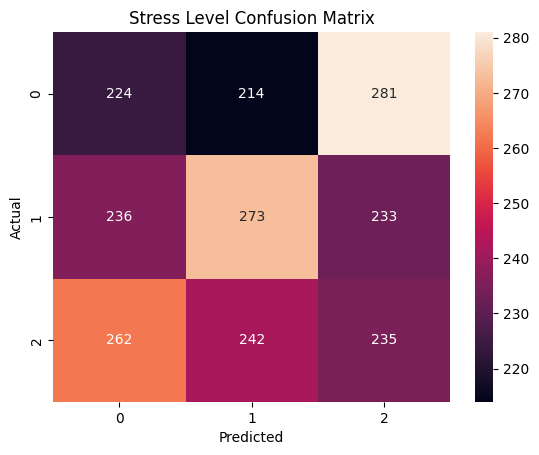

In [24]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y1_test, pred1)

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Stress Level Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [25]:
X2 = data.drop('productivity_score', axis=1)
y2 = data['productivity_score']

In [26]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

In [27]:
from sklearn.ensemble import RandomForestRegressor

reg = RandomForestRegressor()

reg.fit(X2_train, y2_train)

RandomForestRegressor()

In [28]:
from sklearn.metrics import r2_score

pred2 = reg.predict(X2_test)

print("R2 Score:", r2_score(y2_test, pred2))

R2 Score: -0.03705232569509609


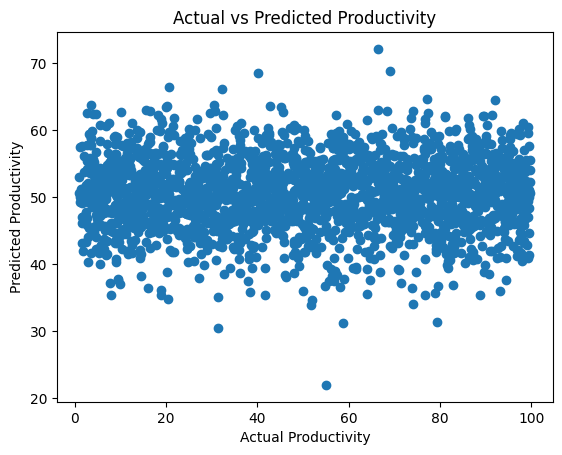

In [29]:
plt.scatter(y2_test, pred2)

plt.xlabel("Actual Productivity")
plt.ylabel("Predicted Productivity")

plt.title("Actual vs Predicted Productivity")

plt.show()

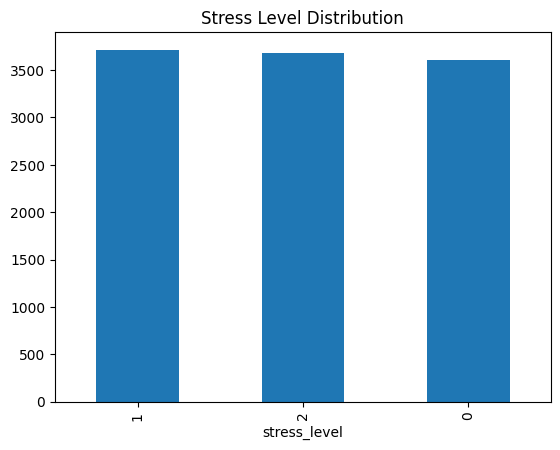

In [30]:
data['stress_level'].value_counts().plot(kind='bar')

plt.title("Stress Level Distribution")

plt.show()